
O_R1s(r) =
+27.3434 * exp(-11.2970 r)
+15.8117 * exp(-6.5966 r)
-15.1029 * r^2 * exp(-20.5019 r)
+67.9178 * r * exp(-9.5546 r)
+0.0443 * r * exp(-3.2482 r)
+0.0017 * r * exp(-2.1608 r)
+0.0005 * r * exp(-1.6411 r)

O_R2s(r) =
-4.8878 * exp(-11.2970 r)
+14.6786 * exp(-6.5966 r)
-4.5243 * r^2 * exp(-20.5019 r)
-23.6222 * r * exp(-9.5546 r)
-8.1220 * r * exp(-3.2482 r)
-4.0626 * r * exp(-2.1608 r)
-0.9060 * r * exp(-1.6411 r)

O_R2p(r) =
+1.8779 * r * exp(-9.6471 r)
+5.7116 * r * exp(-4.3323 r)
+4.7647 * r * exp(-2.7502 r)
+1.8564 * r * exp(-1.7525 r)
+0.4650 * r * exp(-1.2473 r)


/tmp/ipykernel_4911/422642324.py:74: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)



chi_O_1s(p) = sqrt(2/pi) * [
    +27.3434 * (2*11.2970) / ((11.2970**2 + p**2)**2)
    +15.8117 * (2*6.5966) / ((6.5966**2 + p**2)**2)
    -15.1029 * (24*20.5019*(20.5019**2 - p**2)) / ((20.5019**2 + p**2)**4)
    +67.9178 * (2*(3*9.5546**2 - p**2)) / ((9.5546**2 + p**2)**3)
    +0.0443 * (2*(3*3.2482**2 - p**2)) / ((3.2482**2 + p**2)**3)
    +0.0017 * (2*(3*2.1608**2 - p**2)) / ((2.1608**2 + p**2)**3)
    +0.0005 * (2*(3*1.6411**2 - p**2)) / ((1.6411**2 + p**2)**3)
]

I_O_1s(p) = (2/pi) * p**2 * [
    +27.3434 * (2*11.2970) / ((11.2970**2 + p**2)**2)
    +15.8117 * (2*6.5966) / ((6.5966**2 + p**2)**2)
    -15.1029 * (24*20.5019*(20.5019**2 - p**2)) / ((20.5019**2 + p**2)**4)
    +67.9178 * (2*(3*9.5546**2 - p**2)) / ((9.5546**2 + p**2)**3)
    +0.0443 * (2*(3*3.2482**2 - p**2)) / ((3.2482**2 + p**2)**3)
    +0.0017 * (2*(3*2.1608**2 - p**2)) / ((2.1608**2 + p**2)**3)
    +0.0005 * (2*(3*1.6411**2 - p**2)) / ((1.6411**2 + p**2)**3)
]**2

chi_O_2s(p) = sqrt(2/pi) * [
    -4.8878 * (2*1

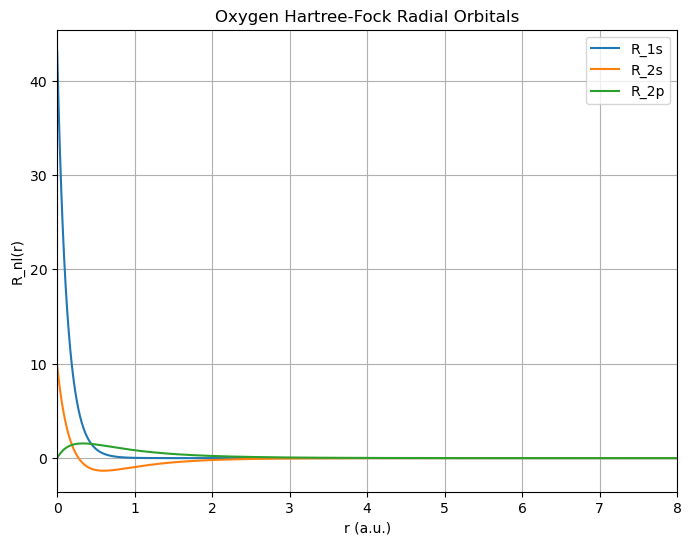

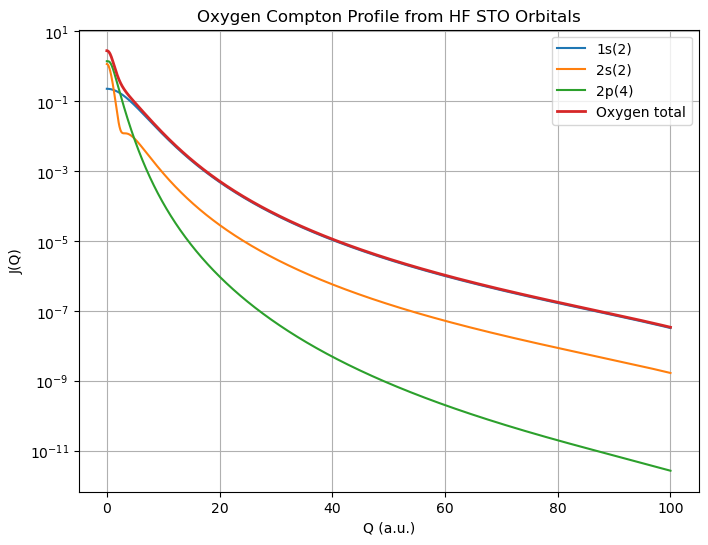

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import spherical_jn, factorial
from scipy.integrate import cumulative_trapezoid

# =====================================================
# Oxygen Hartree-Fock STO data
# O: 1s(2) 2s(2) 2p(4)
# Format: (n_j, Z_j, C_j)
# =====================================================

oxygen_1s = [
    (1, 11.2970,  0.360063),
    (1,  6.5966,  0.466625),
    (3, 20.5019, -0.000918),
    (2,  9.5546,  0.208441),
    (2,  3.2482,  0.002018),
    (2,  2.1608,  0.000216),
    (2,  1.6411,  0.000133),
]

oxygen_2s = [
    (1, 11.2970, -0.064363),
    (1,  6.5966,  0.433186),
    (3, 20.5019, -0.000275),
    (2,  9.5546, -0.072497),
    (2,  3.2482, -0.369900),
    (2,  2.1608, -0.512627),
    (2,  1.6411, -0.227421),
]

oxygen_2p = [
    (2, 9.6471, 0.005626),
    (2, 4.3323, 0.126618),
    (2, 2.7502, 0.328966),
    (2, 1.7525, 0.395422),
    (2, 1.2473, 0.231788),
]
# =====================================================
# STO normalization constant
# N_j = sqrt((2Z)^(2n+1)/(2n)!)
# =====================================================

def N_sto(n, Z):
    return np.sqrt((2*Z)**(2*n + 1) / factorial(2*n, exact=False))

def R_nl(r, coeffs):
    R = np.zeros_like(r)
    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        R += C * N * r**(n-1) * np.exp(-Z*r)
    return R

# =====================================================
# Grids
# =====================================================

r = np.linspace(1e-6, 60.0, 20000)     # radial grid
p = np.arange(0.0, 120.0 + 0.05, 0.05) # momentum grid
Q = np.arange(0.0, 100.0 + 0.05, 0.05) # Q grid

# =====================================================
# Calculate chi_nl(p)
# chi_nl(p) = sqrt(2/pi) int R_nl(r) j_l(pr) r^2 dr
# =====================================================

def chi_p(p_grid, r_grid, R_grid, l):
    chi = []

    for pp in p_grid:
        jl = spherical_jn(l, pp*r_grid)
        integrand = R_grid * jl * r_grid**2
        val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)
        chi.append(val)

    return np.array(chi)

# =====================================================
# Calculate J(Q)
# I(p) = |chi(p)|^2 p^2
# J(Q) = 1/2 int_Q^inf I(p)/p dp
# =====================================================

def calculate_J(p_grid, chi_grid, Q_grid):
    I = chi_grid**2 * p_grid**2

    integrand = np.zeros_like(p_grid)
    integrand[1:] = I[1:] / p_grid[1:]

    # Reverse cumulative integral from p to infinity
    rev_integral = cumulative_trapezoid(
        integrand[::-1],
        p_grid[::-1],
        initial=0
    )

    J_p = -0.5 * rev_integral[::-1]

    # Interpolate J from p-grid to Q-grid
    J_Q = np.interp(Q_grid, p_grid, J_p)

    return I, J_Q

# =====================================================
# Build oxygen radial orbitals
# =====================================================
R1s = R_nl(r, oxygen_1s)
R2s = R_nl(r, oxygen_2s)
R2p = R_nl(r, oxygen_2p)

print_R_formula(oxygen_1s, "O_R1s")
print_R_formula(oxygen_2s, "O_R2s")
print_R_formula(oxygen_2p, "O_R2p")

chi_1s = chi_p(p, r, R1s, l=0)
chi_2s = chi_p(p, r, R2s, l=0)
chi_2p = chi_p(p, r, R2p, l=1)

I_1s, J_1s = calculate_J(p, chi_1s, Q)
I_2s, J_2s = calculate_J(p, chi_2s, Q)
I_2p, J_2p = calculate_J(p, chi_2p, Q)

print_chi_I_full_s(oxygen_1s, "O_1s")
print_chi_I_full_s(oxygen_2s, "O_2s")
print_chi_I_full_p(oxygen_2p, "O_2p")

# Oxygen has 1s(2) 2s(2) 2p(4)
J_total = 2*J_1s + 2*J_2s + 4*J_2p


# =====================================================
# Print and save table
# =====================================================

table = pd.DataFrame({
    "Q": Q,
    "J_1s_one_electron": J_1s,
    "J_2s_one_electron": J_2s,
    "J_2p_one_electron": J_2p,
    "J_1s(2)": 2*J_1s,
    "J_2s(2)": 2*J_2s,
    "J_2p(4)": 4*J_2p,
    "J_total_carbon": J_total
})

pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.6e}".format)

print(table)

table.to_csv("oxygen2_HF2_Compton_profile.csv", index=False)
print("\nSaved: carbon_HF2_Compton_profile.csv")

# =====================================================
# Plot radial orbitals
# =====================================================

plt.figure(figsize=(8,6))
plt.plot(r, R1s, label="R_1s")
plt.plot(r, R2s, label="R_2s")
plt.plot(r, R2p, label="R_2p")
plt.xlim(0, 8)
plt.xlabel("r (a.u.)")
plt.ylabel("R_nl(r)")
plt.title("Oxygen Hartree-Fock Radial Orbitals")
plt.grid(True)
plt.legend()
plt.show()

# =====================================================
# Plot Compton profiles
# =====================================================

plt.figure(figsize=(8,6))
plt.plot(Q, 2*J_1s, label="1s(2)")
plt.plot(Q, 2*J_2s, label="2s(2)")
plt.plot(Q, 4*J_2p, label="2p(4)")
plt.plot(Q, J_total, label="Oxygen total", linewidth=2)

plt.xlabel("Q (a.u.)")
plt.ylabel("J(Q)")
plt.title("Oxygen Compton Profile from HF STO Orbitals")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()